In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

Loading the dataset

In [ ]:
data = pd.read_csv('/content/diabetes.csv')

In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Replace columns like (Gluscore,BloodPressure,Skin Thickness,BMI,Insulin) with Zero as values  with mean of respective columns

In [ ]:
Zero_not_accepted = ['Glucose','BloodPressure','SkinThickness','BMI','Insulin']
for col in Zero_not_accepted:
  data[col] = data[col].replace(0,np.nan)
  mean = int(data[col].mean(skipna = True))
  data[col] = data[col].replace(np.nan,mean)

In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,155.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,155.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,155.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


Extracting the independent variables from the data

In [ ]:
x = data.iloc[:, 0:8]
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,155.0,33.6,0.627,50
1,1,85.0,66.0,29.0,155.0,26.6,0.351,31
2,8,183.0,64.0,29.0,155.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63
764,2,122.0,70.0,27.0,155.0,36.8,0.340,27
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
766,1,126.0,60.0,29.0,155.0,30.1,0.349,47


exctraing the depedent varibles from the data

In [ ]:
y = data.iloc[:, 8]
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


**EDA**

<Axes: >

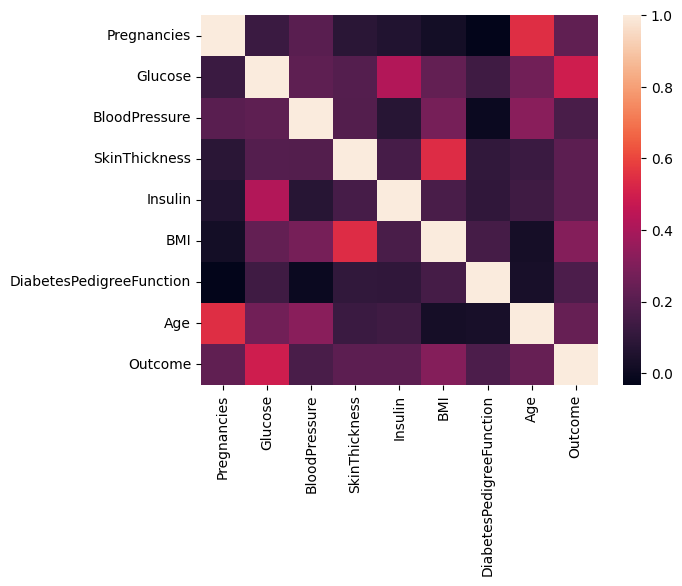

In [ ]:
sns.heatmap(data.corr())

<Axes: xlabel='Age', ylabel='count'>

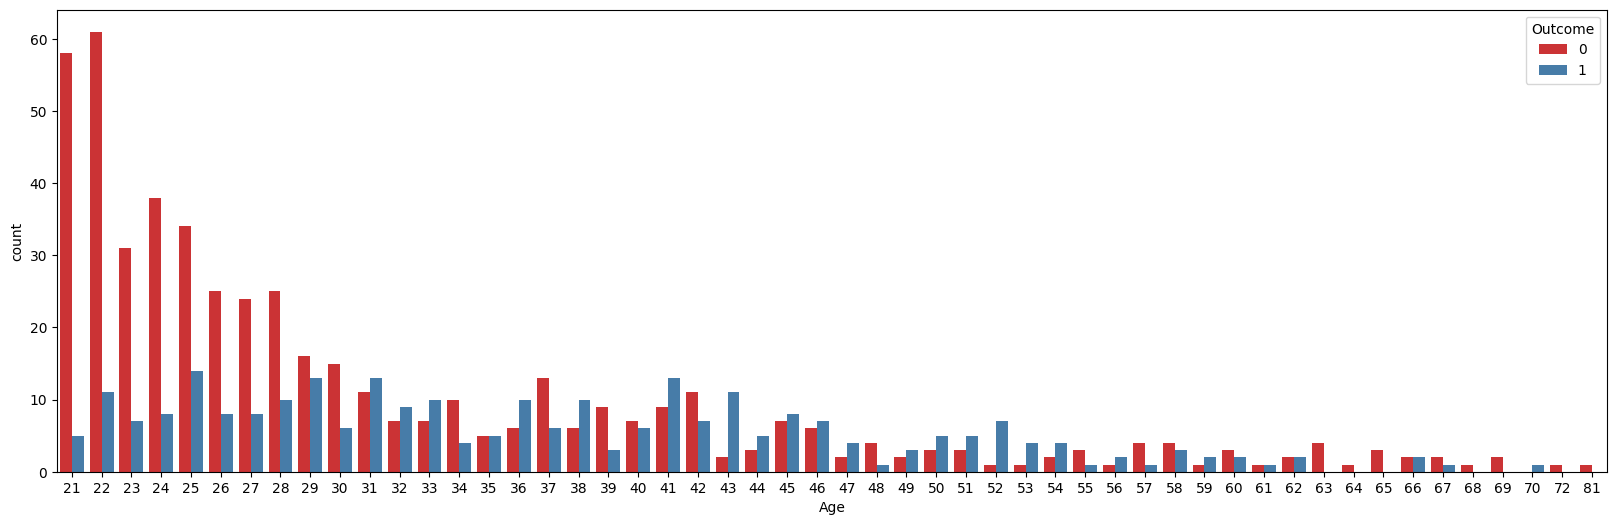

In [ ]:
plt.figure(figsize = (20,6))
sns.countplot(x = 'Age',hue='Outcome',data = data,palette='Set1')

Split_train_test

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=10)

In [ ]:
x_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
120,0,162.0,76.0,56.0,100.0,53.2,0.759,25
172,2,87.0,72.0,23.0,155.0,28.9,0.773,25
307,0,137.0,68.0,14.0,148.0,24.8,0.143,21
7,10,115.0,72.0,29.0,155.0,35.3,0.134,29
448,0,104.0,64.0,37.0,64.0,33.6,0.510,22


feature scaling

In [23]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)    # in the Pi to -pi

In [24]:
x_test

array([[ 0.04858483,  1.02206677, -0.0521296 , ..., -0.1422535 ,
        -0.3818644 ,  0.32262081],
       [-0.54212969, -0.32605137,  1.09981397, ...,  0.89894851,
        -0.66362514, -0.44318786],
       [-0.83748694,  0.4122038 , -1.53319991, ..., -0.81683509,
         0.68698881,  2.44986711],
       ...,
       [ 1.23001385, -1.19269875, -1.45091823, ..., -1.15412589,
        -1.00051297,  0.74807007],
       [ 0.34394208,  0.25171354,  0.77068724, ...,  1.00160224,
         1.51083269,  0.32262081],
       [-0.24677243, -0.74332604, -1.53319991, ..., -0.97814808,
        -0.94538587, -0.78354727]])

loading KNN model

In [26]:
classifier = KNeighborsClassifier(n_neighbors=11,p = 2, metric = 'euclidean')

In [27]:
# fitting the model
model = classifier.fit(x_train,y_train)

In [29]:
y_pred = model.predict(x_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [30]:
y_test

,Outcome
568,0
620,0
456,0
197,1
714,0
...,...
264,1
706,1
194,0
179,1


Evaluation model

In [31]:
confusion_matrix(y_test,y_pred)

array([[81, 14],
       [30, 29]])

In [32]:
((81+29)/(81+14+30+29))*100

71.42857142857143

In [33]:
print(accuracy_score(y_test,y_pred))


0.7142857142857143


In [34]:
print(f1_score(y_test,y_pred))

0.5686274509803921


In [36]:
classifier = KNeighborsClassifier(n_neighbors=11,p = 2, metric = 'euclidean')

In [38]:
for i in range(1,6):
  classifier = KNeighborsClassifier(n_neighbors=i,p = 2, metric = 'euclidean')

# If you want to see the final classifier, you can remove the 'return' and just have `classifier` as the last line
classifier

KNeighborsClassifier(metric='euclidean')

for to **find the best accuracy_score** between the 1-6


In [43]:
classifier = KNeighborsClassifier(n_neighbors=1,p = 2, metric = 'euclidean')

In [44]:
model = classifier.fit(x_train,y_train)

In [49]:
y_pred1 = model.predict(x_test)
y_pred1

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0])

In [50]:
print(accuracy_score(y_test,y_pred1))

0.7012987012987013


In [51]:
classifier = KNeighborsClassifier(n_neighbors=2,p = 2, metric = 'euclidean')

In [52]:
model = classifier.fit(x_train,y_train)

In [53]:
y_pred2 = model.predict(x_test)
y_pred2

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0])

In [54]:
print(accuracy_score(y_test,y_pred2))

0.7207792207792207
